<a href="https://colab.research.google.com/github/abdulahad934/01.-project-one/blob/main/train_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('train.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df['Order Date'].head(15).tolist()


['08/11/2017',
 '08/11/2017',
 '12/06/2017',
 '11/10/2016',
 '11/10/2016',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015',
 '15/04/2018',
 '05/12/2017',
 '22/11/2016']

In [ ]:
df['Ship Date'].head(15).tolist()

['11/11/2017',
 '11/11/2017',
 '16/06/2017',
 '18/10/2016',
 '18/10/2016',
 '14/06/2015',
 '14/06/2015',
 '14/06/2015',
 '14/06/2015',
 '14/06/2015',
 '14/06/2015',
 '14/06/2015',
 '20/04/2018',
 '10/12/2017',
 '26/11/2016']

In [ ]:
def detect_column_category(col, dtype):
  col_lower = col.lower()
  nunique = df[col].nunique()


  if 'id' in col_lower or 'row' in col_lower:
    return "Not Plot"
  if 'date' in col_lower or dtype.startswith('datetime'):
    return "datetime-series"
  if  dtype in ["int64", "float64"]:
    return "Numerical (Boxplot, Histplot)"

  return "Categorical plot (CountPlot)"



column_info = pd.DataFrame({
    "column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Cetagory": [detect_column_category(col, str(df[col].dtype)) for col in df.columns]
})


print(column_info)


                      column Data Type                       Cetagory
Row ID                Row ID     int64                       Not Plot
Order ID            Order ID    object                       Not Plot
Order Date        Order Date    object                datetime-series
Ship Date          Ship Date    object                datetime-series
Ship Mode          Ship Mode    object   Categorical plot (CountPlot)
Customer ID      Customer ID    object                       Not Plot
Customer Name  Customer Name    object   Categorical plot (CountPlot)
Segment              Segment    object   Categorical plot (CountPlot)
Country              Country    object   Categorical plot (CountPlot)
City                    City    object   Categorical plot (CountPlot)
State                  State    object   Categorical plot (CountPlot)
Postal Code      Postal Code   float64  Numerical (Boxplot, Histplot)
Region                Region    object   Categorical plot (CountPlot)
Product ID        Pr

In [ ]:
df.shape

(9800, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
print("Missing Values /n", df.isnull().sum())

Missing Values /n Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [ ]:
column_info

,column,Data Type,Cetagory
Row ID,Row ID,int64,Not Plot
Order ID,Order ID,object,Not Plot
Order Date,Order Date,object,datetime-series
Ship Date,Ship Date,object,datetime-series
Ship Mode,Ship Mode,object,Categorical plot (CountPlot)
Customer ID,Customer ID,object,Not Plot
Customer Name,Customer Name,object,Categorical plot (CountPlot)
Segment,Segment,object,Categorical plot (CountPlot)
Country,Country,object,Categorical plot (CountPlot)
City,City,object,Categorical plot (CountPlot)


In [ ]:
numerical_col = ['Postal Code', 'Sales']

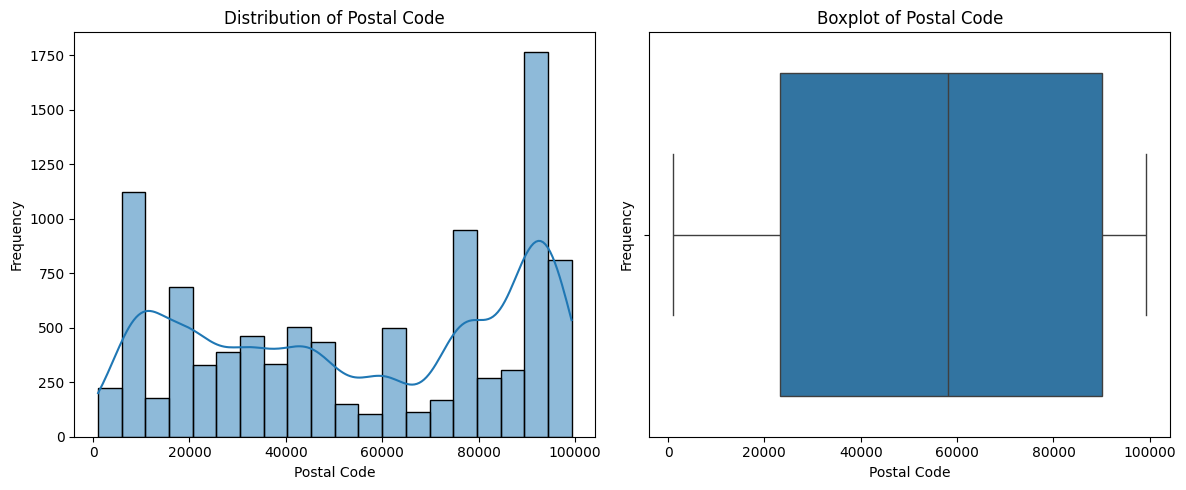

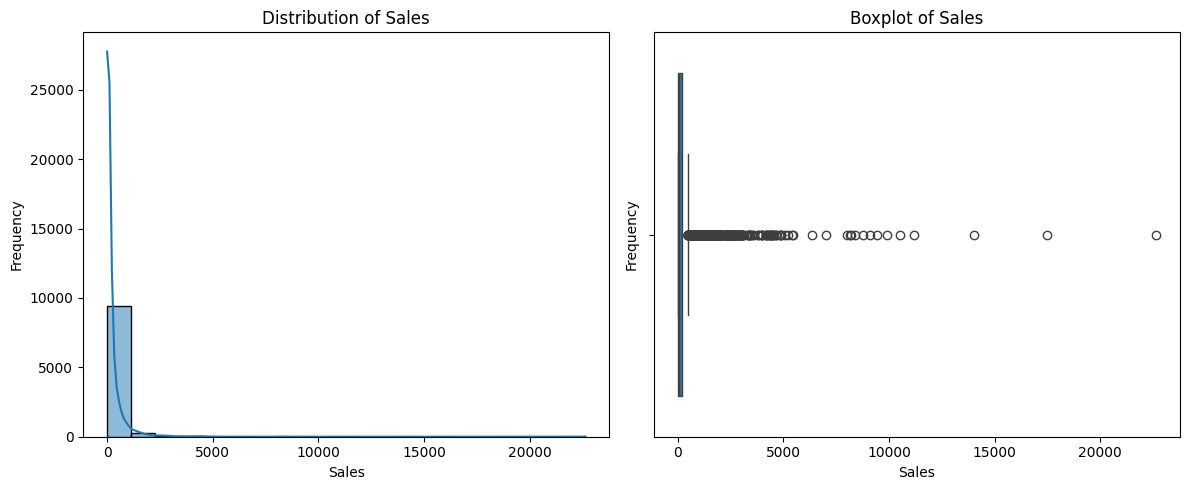

In [ ]:
for col in numerical_col:
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  sns.histplot(df[col], kde=True, bins= 20)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")

  plt.subplot(1, 2, 2)
  sns.boxplot(data=df, x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.tight_layout()
  plt.show()

In [ ]:
column_info

,column,Data Type,Cetagory
Row ID,Row ID,int64,Not Plot
Order ID,Order ID,object,Not Plot
Order Date,Order Date,object,datetime-series
Ship Date,Ship Date,object,datetime-series
Ship Mode,Ship Mode,object,Categorical plot (CountPlot)
Customer ID,Customer ID,object,Not Plot
Customer Name,Customer Name,object,Categorical plot (CountPlot)
Segment,Segment,object,Categorical plot (CountPlot)
Country,Country,object,Categorical plot (CountPlot)
City,City,object,Categorical plot (CountPlot)


In [ ]:
cetagorical_plot = ['Ship Mode', 'Customer Name', 'Segment', 'Country', 'City', 'State',
                    'Region', 'Category', 'Product Name']

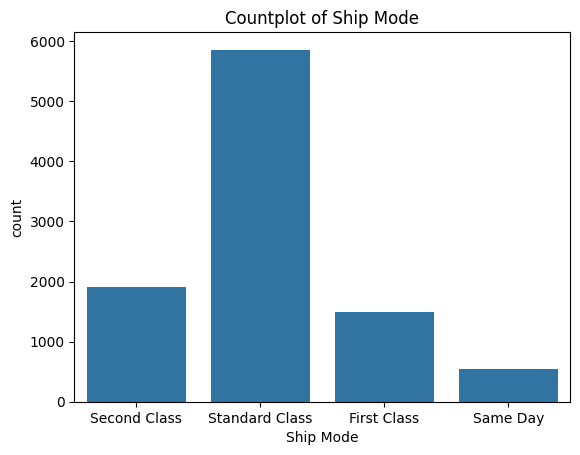

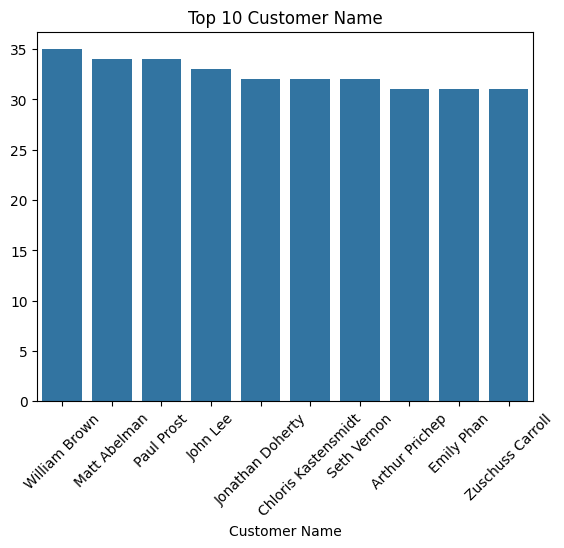

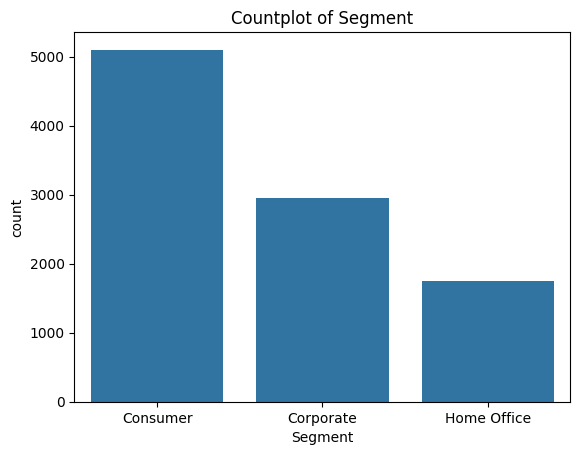

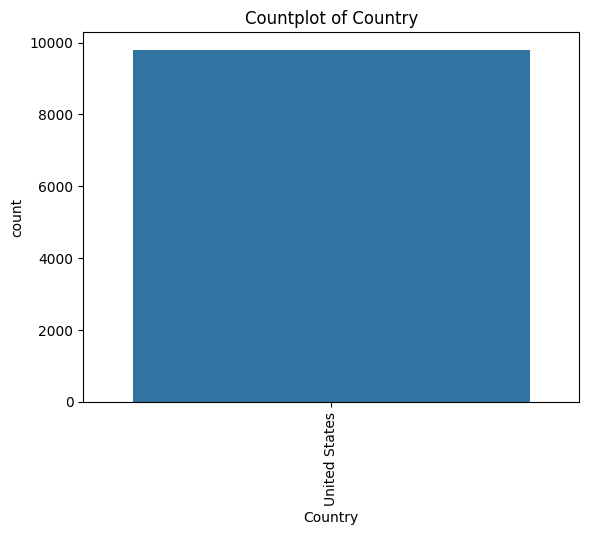

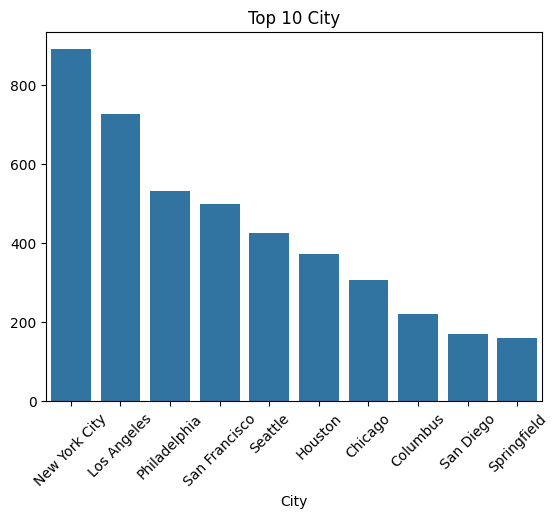

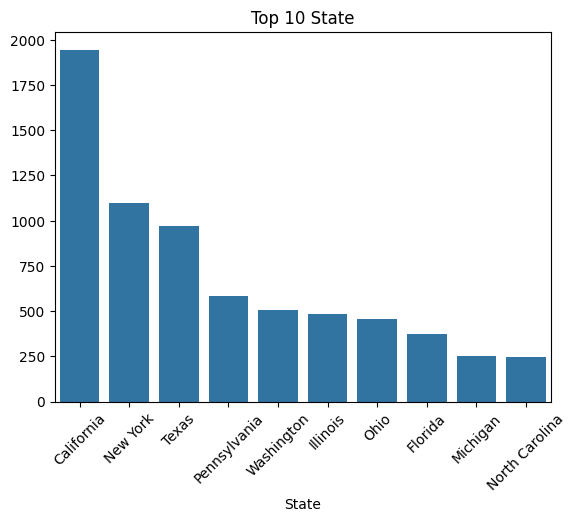

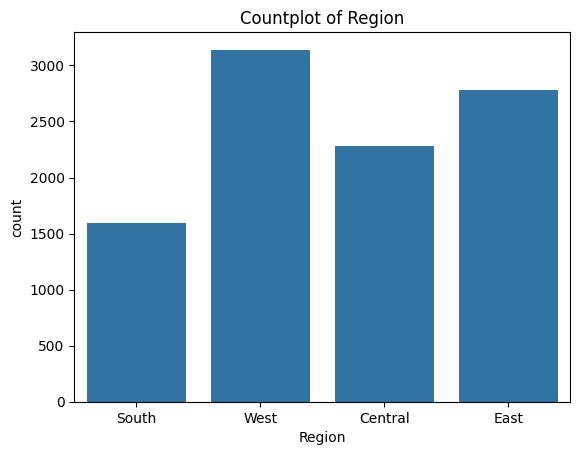

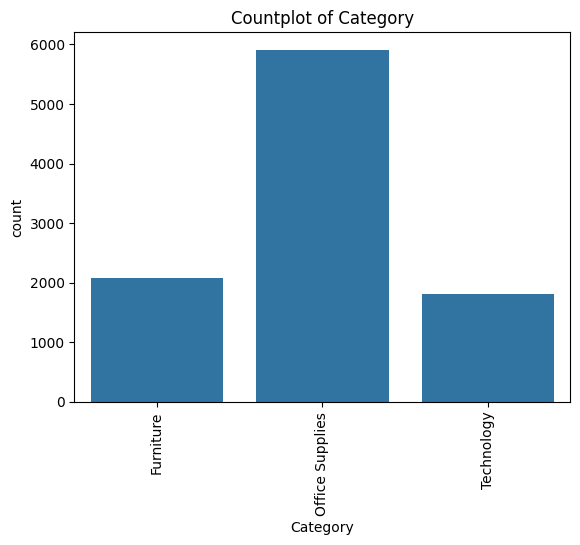

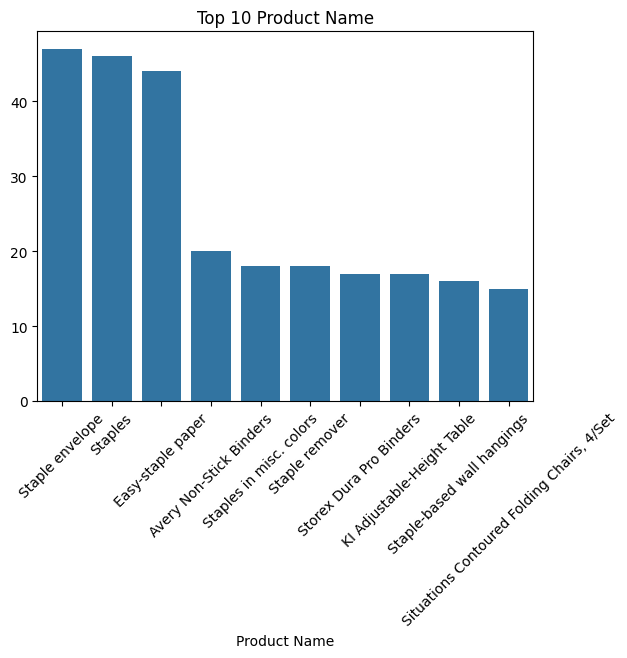

In [ ]:

for col in cetagorical_plot:
    if df[col].nunique() <= 20:
        sns.countplot(data=df, x=col)
        plt.title(f"Countplot of {col}")
        plt.show()
        plt.xticks(rotation=90)
    else:
        # High-cardinality → top 10
        top_values = df[col].value_counts().head(10)
        sns.barplot(x=top_values.index, y=top_values.values)
        plt.title(f"Top 10 {col}")
        plt.xticks(rotation=45)
        plt.show()

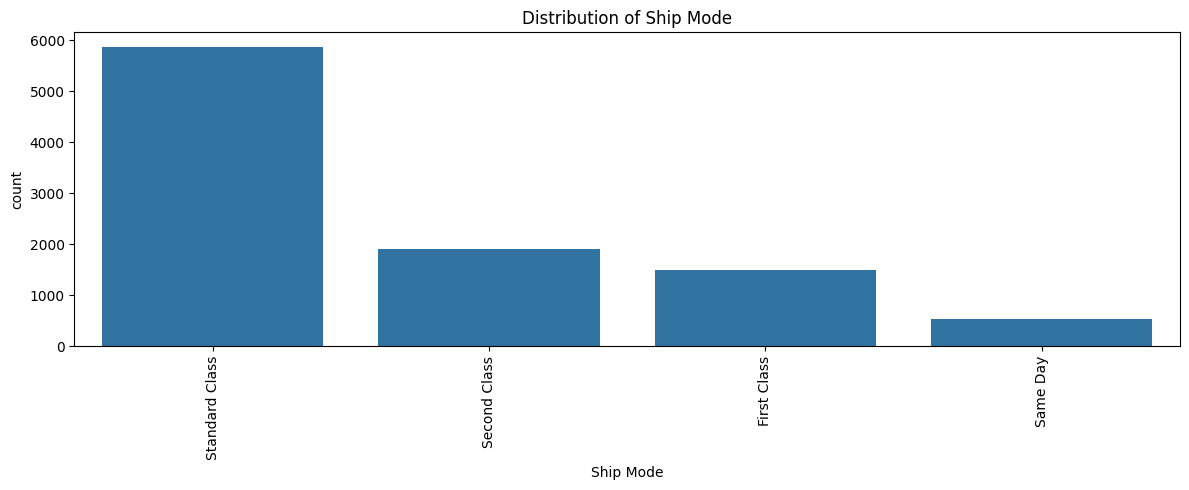

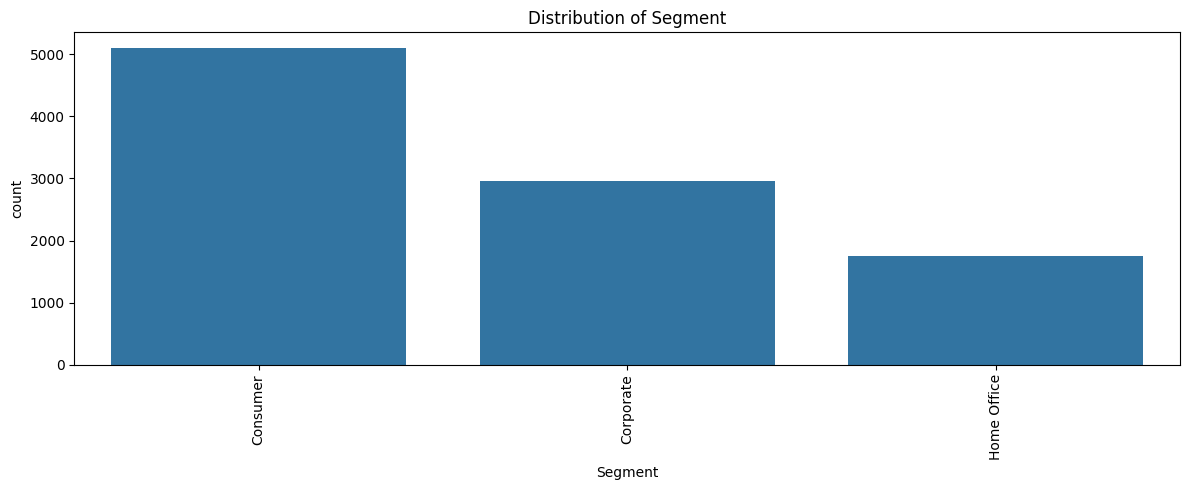

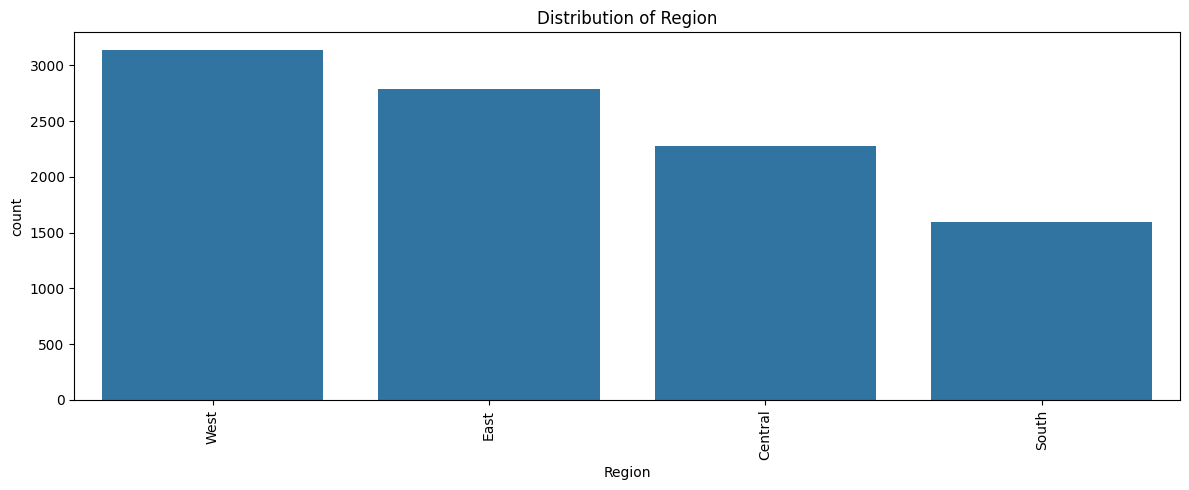

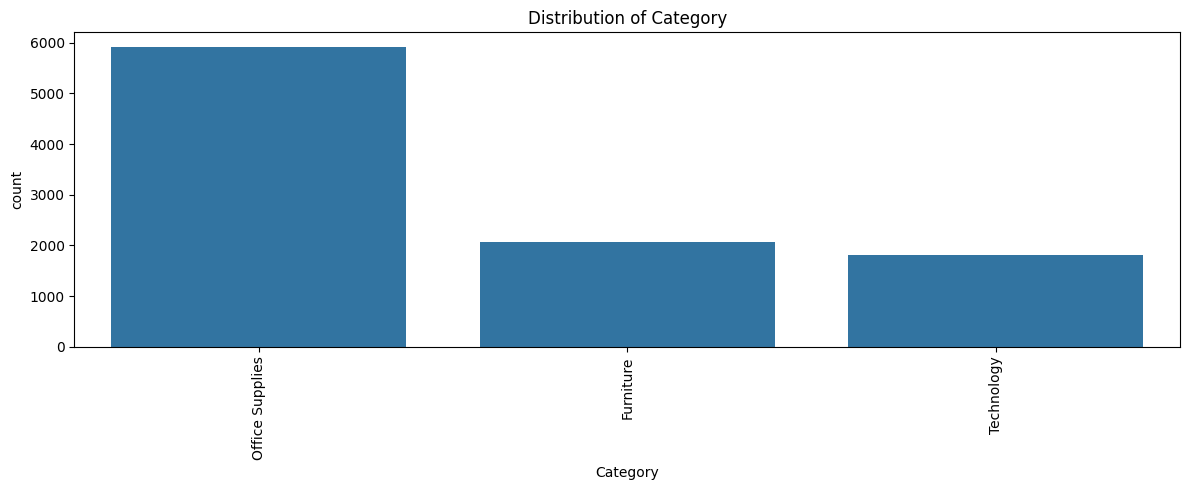

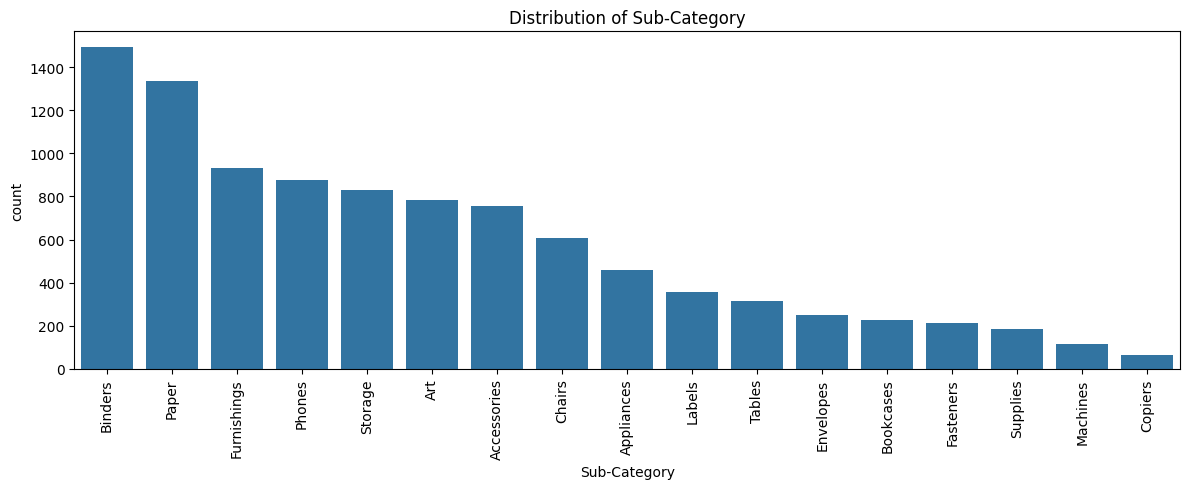

In [ ]:
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
for col in cat_cols:
  plt.figure(figsize=(12, 5))
  sns.countplot(data=df, x=col, order=df[col].value_counts().index)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel('count')
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')


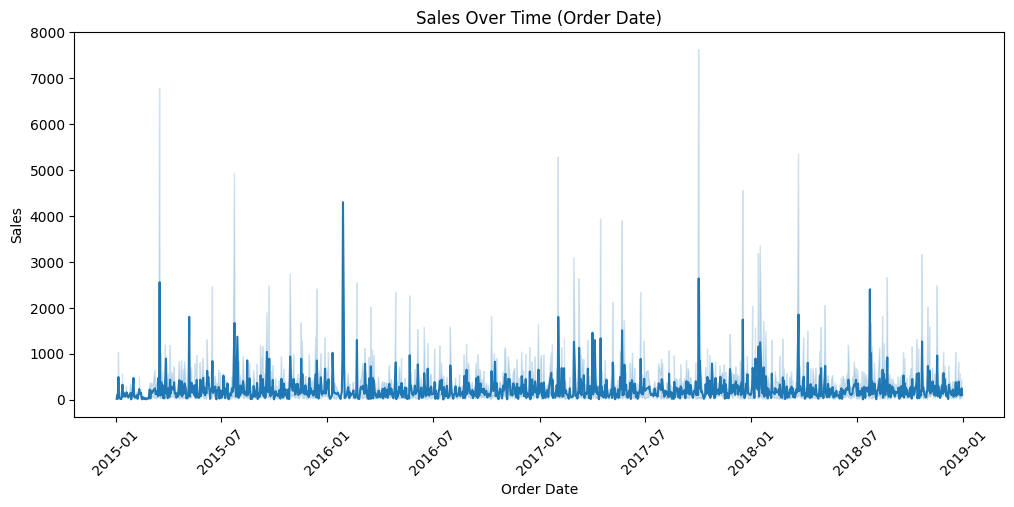

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='Order Date', y='Sales')
plt.title("Sales Over Time (Order Date)")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

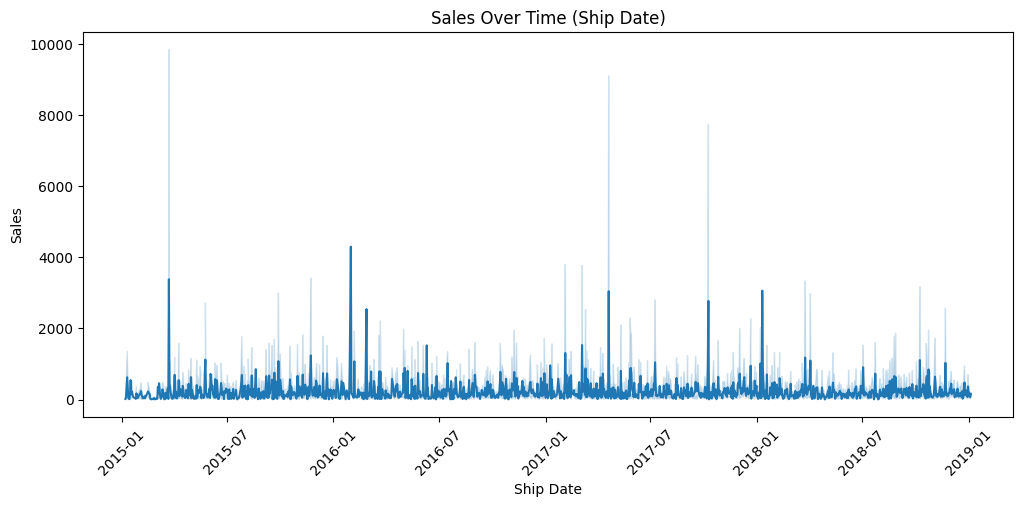

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='Ship Date', y='Sales')
plt.title("Sales Over Time (Ship Date)")
plt.xlabel("Ship Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


In [ ]:
df.shape

(9800, 18)

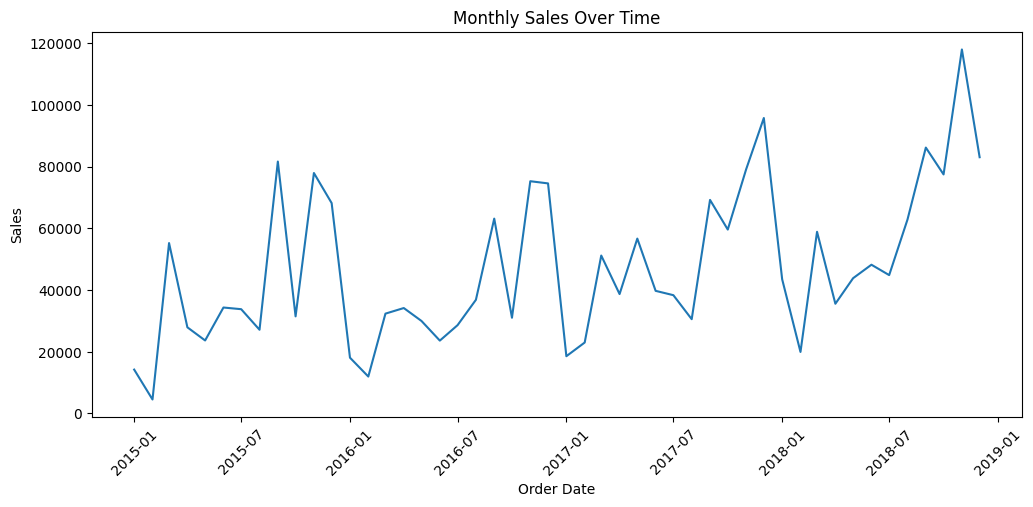

In [ ]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Order Date', y='Sales')
plt.title("Monthly Sales Over Time")
plt.xticks(rotation=45)
plt.show()


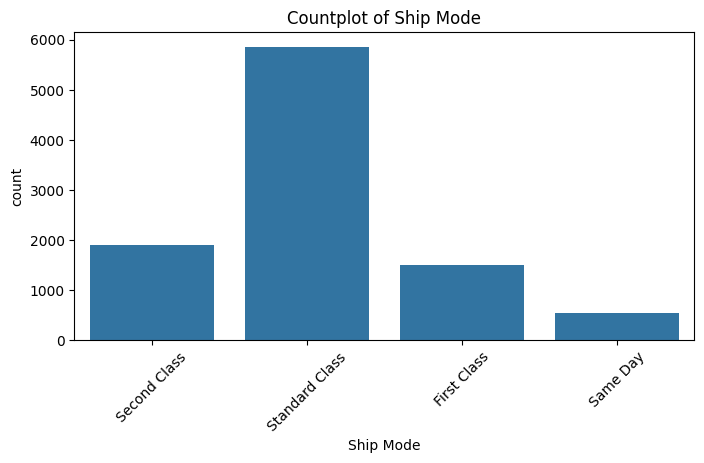

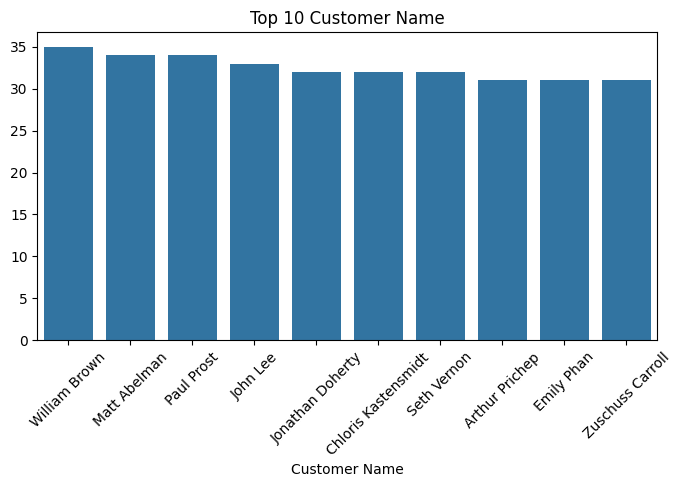

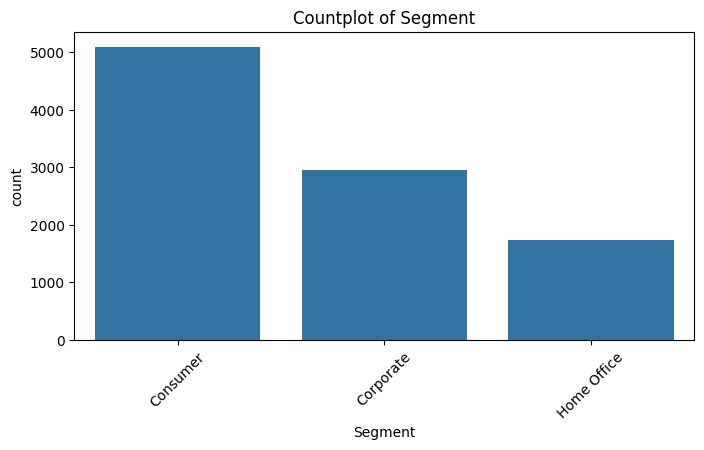

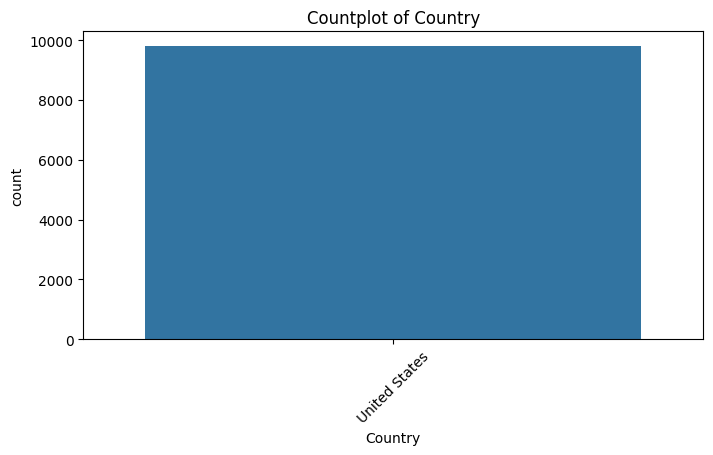

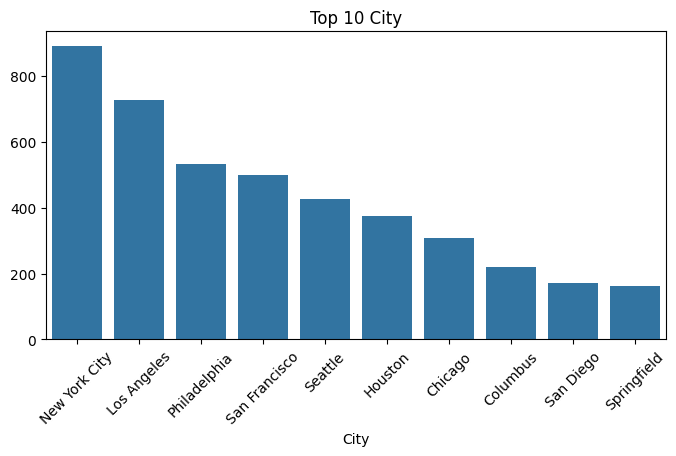

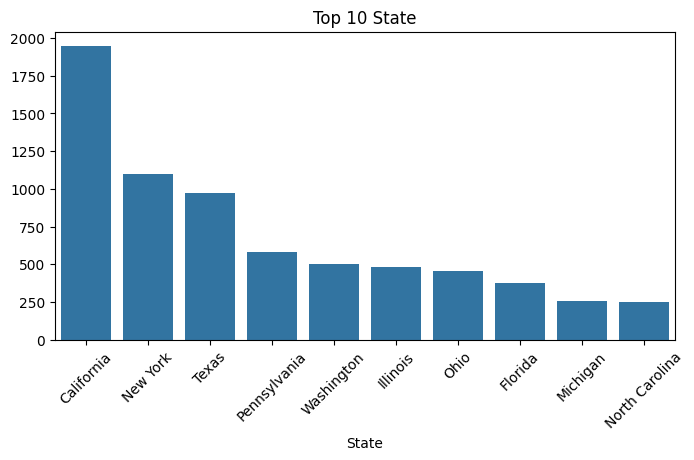

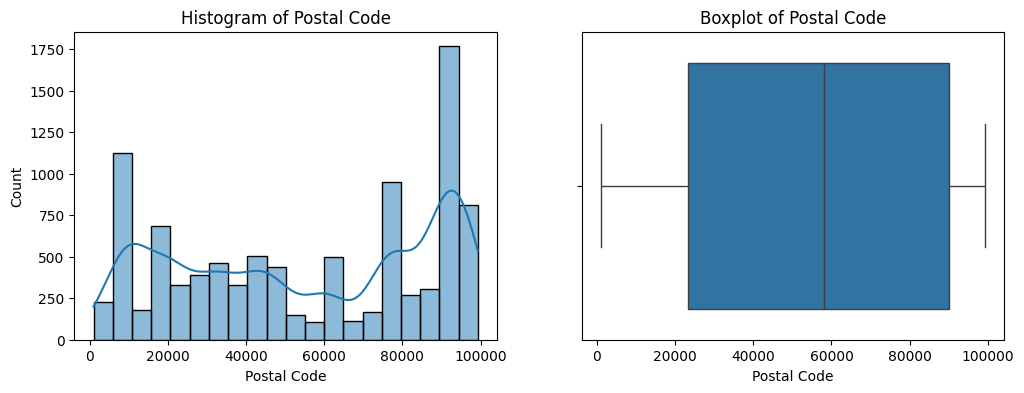

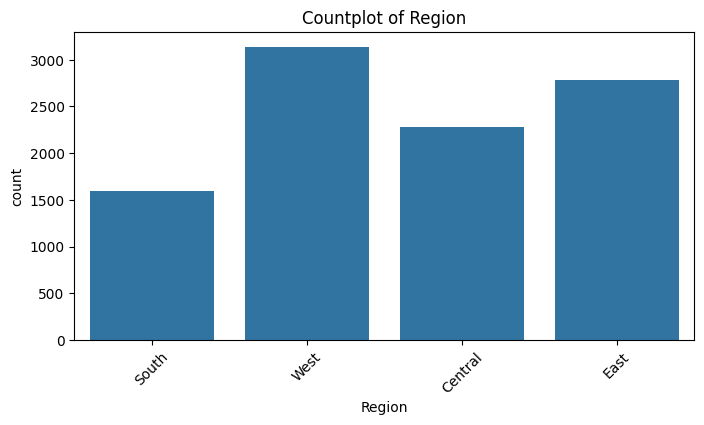

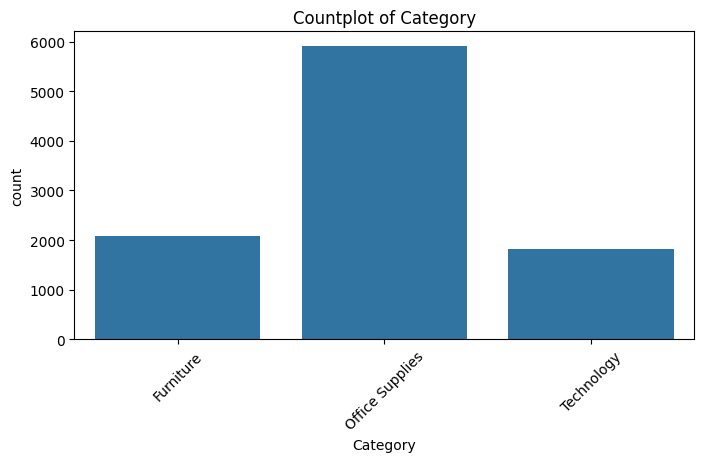

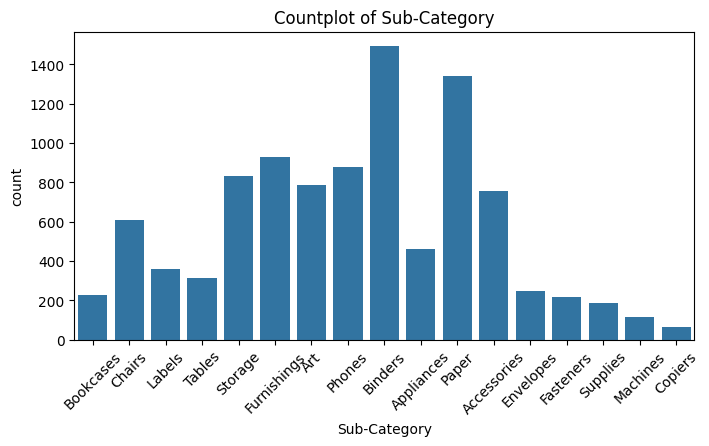

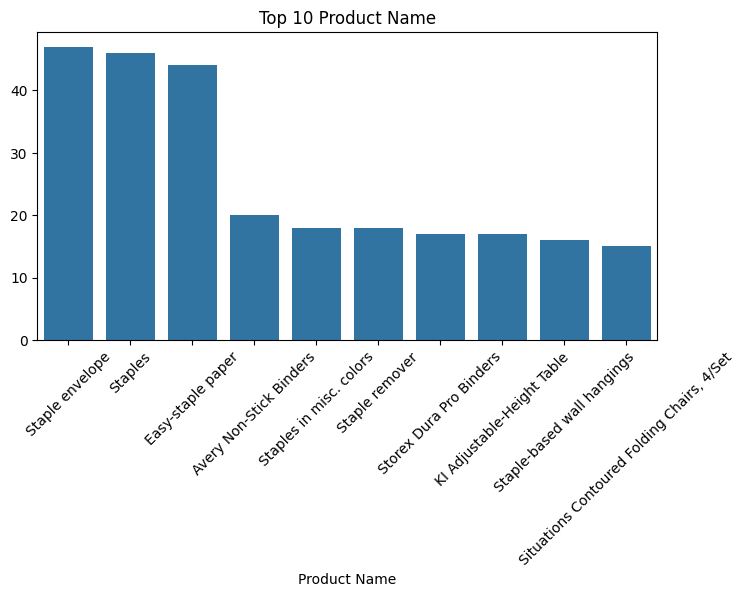

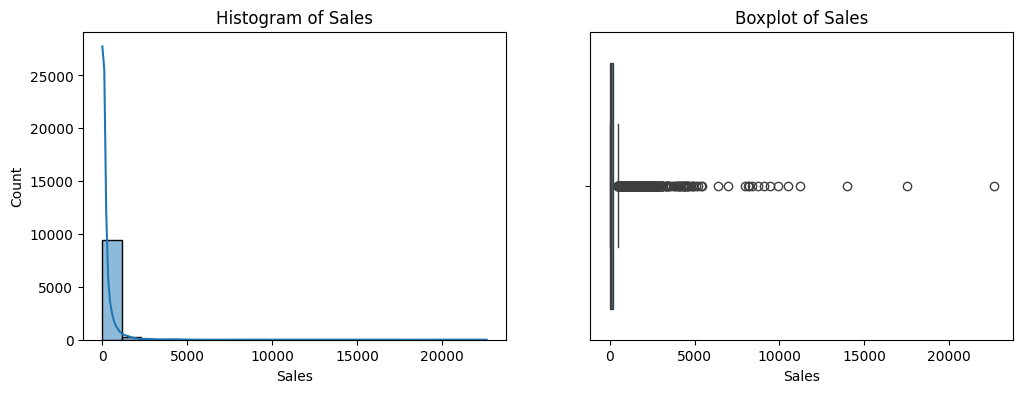

In [ ]:
for col in df.columns:
    category = detect_column_category(col, str(df[col].dtype))

    if category == "Not Plot":
        continue

    elif category == "Datetime-series":
        # Daily plot
        plt.figure(figsize=(12,5))
        numeric_col = df.select_dtypes(include=["number"]).columns[0]  # প্রথম numeric column
        sns.lineplot(data=df, x=col, y=numeric_col)
        plt.title(f"{numeric_col} over Time ({col})")
        plt.xlabel(col)
        plt.ylabel(numeric_col)
        plt.xticks(rotation=45)
        plt.show()

        # Monthly aggregation
        df[col] = pd.to_datetime(df[col])
        monthly = df.groupby(df[col].dt.to_period('M'))[numeric_col].sum().reset_index()
        monthly[col] = monthly[col].dt.to_timestamp()
        plt.figure(figsize=(12,5))
        sns.lineplot(data=monthly, x=col, y=numeric_col)
        plt.title(f"Monthly {numeric_col} over Time ({col})")
        plt.xticks(rotation=45)
        plt.show()

    elif category == "Numerical (Boxplot, Histplot)":
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        sns.histplot(df[col], kde=True, bins=20)
        plt.title(f"Histogram of {col}")
        plt.subplot(1,2,2)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

    elif category == "Categorical plot (CountPlot)":
        if df[col].nunique() <= 20:
            plt.figure(figsize=(8,4))
            sns.countplot(data=df, x=col)
            plt.title(f"Countplot of {col}")
            plt.xticks(rotation=45)
            plt.show()
        else:
            top_values = df[col].value_counts().head(10)
            plt.figure(figsize=(8,4))
            sns.barplot(x=top_values.index, y=top_values.values)
            plt.title(f"Top 10 {col}")
            plt.xticks(rotation=45)
            plt.show()

In [ ]:
df_cleaned = df.copy()

In [ ]:
print("Missing values:/n", df_cleaned.isnull().sum())

Missing values:/n Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [ ]:
df_cleaned[['Order Date','Ship Date']].isna().sum()


,0
Order Date,0
Ship Date,0


In [ ]:
# df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], format='%d-%m-%Y', errors='coerce')
# df_cleaned['Ship Date'] = pd.to_datetime(df_cleaned['Ship Date'], format='%m/%d/%Y', errors='coerce')


In [ ]:
# df_cleaned[['Order Date', 'Ship Date']].head(20)


In [ ]:
# df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], errors='coerce')
# df_cleaned['Ship Date'] = pd.to_datetime(df_cleaned['Ship Date'], errors='coerce', dayfirst=False)
# df_cleaned[['Order Date', 'Ship Date']].isna().sum()


In [ ]:
# df_cleaned[['Order Date', 'Ship Date']].head(20)


In [ ]:
df['Ship Date'].head(15).tolist()


[Timestamp('2017-11-11 00:00:00'),
 Timestamp('2017-11-11 00:00:00'),
 Timestamp('2017-06-16 00:00:00'),
 Timestamp('2016-10-18 00:00:00'),
 Timestamp('2016-10-18 00:00:00'),
 Timestamp('2015-06-14 00:00:00'),
 Timestamp('2015-06-14 00:00:00'),
 Timestamp('2015-06-14 00:00:00'),
 Timestamp('2015-06-14 00:00:00'),
 Timestamp('2015-06-14 00:00:00'),
 Timestamp('2015-06-14 00:00:00'),
 Timestamp('2015-06-14 00:00:00'),
 Timestamp('2018-04-20 00:00:00'),
 Timestamp('2017-12-10 00:00:00'),
 Timestamp('2016-11-26 00:00:00')]

In [ ]:
print("Missing Values:/n", df_cleaned.isna().sum())

Missing Values:/n Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [ ]:
df_cleaned['Postal Code'].fillna(df_cleaned['Postal Code'].mode()[0], inplace=True)

In [ ]:
df_cleaned.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df_cleaned.duplicated().sum()

np.int64(0)

In [ ]:
df_cleaned.drop_duplicates(inplace=True)

In [ ]:
column_info

,column,Data Type,Cetagory
Row ID,Row ID,int64,Not Plot
Order ID,Order ID,object,Not Plot
Order Date,Order Date,object,datetime-series
Ship Date,Ship Date,object,datetime-series
Ship Mode,Ship Mode,object,Categorical plot (CountPlot)
Customer ID,Customer ID,object,Not Plot
Customer Name,Customer Name,object,Categorical plot (CountPlot)
Segment,Segment,object,Categorical plot (CountPlot)
Country,Country,object,Categorical plot (CountPlot)
City,City,object,Categorical plot (CountPlot)


In [ ]:
cat_cols = ['Ship Mode', 'Customer Name', 'Segment', 'Country', 'City', 'State',
            'Region', 'Category', 'Sub-Category', 'Product Name']

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encode_cols = ['Customer Name', 'Product Name', 'City', 'State', 'Country',]
for col in label_encode_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])


In [ ]:
onehot_encode_cols = ['Ship Mode', 'Segment',
                      'Region', 'Category', 'Sub-Category']
df_cleaned = pd.get_dummies(df_cleaned, columns=onehot_encode_cols, drop_first=True)

In [ ]:
df_cleaned.head()

,Row ID,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Country,City,State,Postal Code,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,1,CA-2017-152156,2017-11-08,2017-11-11,CG-12520,166,0,194,15,42420.0,...,False,False,False,False,False,False,False,False,False,False
1,2,CA-2017-152156,2017-11-08,2017-11-11,CG-12520,166,0,194,15,42420.0,...,False,False,False,False,False,False,False,False,False,False
2,3,CA-2017-138688,2017-06-12,2017-06-16,DV-13045,201,0,265,3,90036.0,...,False,False,False,True,False,False,False,False,False,False
3,4,US-2016-108966,2016-10-11,2016-10-18,SO-20335,687,0,153,8,33311.0,...,False,False,False,False,False,False,False,False,False,True
4,5,US-2016-108966,2016-10-11,2016-10-18,SO-20335,687,0,153,8,33311.0,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
# Order Date থেকে features
df_cleaned['Order_Year'] = df_cleaned['Order Date'].dt.year
df_cleaned['Order_Month'] = df_cleaned['Order Date'].dt.month
df_cleaned['Order_Day'] = df_cleaned['Order Date'].dt.day
df_cleaned['Order_Weekday'] = df_cleaned['Order Date'].dt.weekday  # 0=Monday
df_cleaned['Order_Quarter'] = df_cleaned['Order Date'].dt.quarter

# Shipping Days
df_cleaned['Shipping_Days'] = (df_cleaned['Ship Date'] - df_cleaned['Order Date']).dt.days


In [ ]:
df_cleaned.drop(columns=['Order Date','Ship Date'], inplace=True)

In [ ]:
df_cleaned.head(3)

,Row ID,Order ID,Customer ID,Customer Name,Country,City,State,Postal Code,Product ID,Product Name,...,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_Weekday,Order_Quarter,Shipping_Days
0,1,CA-2017-152156,CG-12520,166,0,194,15,42420.0,FUR-BO-10001798,386,...,False,False,False,False,2017,11,8,2,4,3
1,2,CA-2017-152156,CG-12520,166,0,194,15,42420.0,FUR-CH-10000454,838,...,False,False,False,False,2017,11,8,2,4,3
2,3,CA-2017-138688,DV-13045,201,0,265,3,90036.0,OFF-LA-10000240,1432,...,False,False,False,False,2017,6,12,0,2,4


In [ ]:
df_cleaned.shape

(9800, 43)

In [ ]:
bool_cols = df_cleaned.select_dtypes(include='bool').columns
df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(int)


In [ ]:
df_cleaned.head()

,Row ID,Order ID,Customer ID,Customer Name,Country,City,State,Postal Code,Product ID,Product Name,...,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_Weekday,Order_Quarter,Shipping_Days
0,1,CA-2017-152156,CG-12520,166,0,194,15,42420.0,FUR-BO-10001798,386,...,0,0,0,0,2017,11,8,2,4,3
1,2,CA-2017-152156,CG-12520,166,0,194,15,42420.0,FUR-CH-10000454,838,...,0,0,0,0,2017,11,8,2,4,3
2,3,CA-2017-138688,DV-13045,201,0,265,3,90036.0,OFF-LA-10000240,1432,...,0,0,0,0,2017,6,12,0,2,4
3,4,US-2016-108966,SO-20335,687,0,153,8,33311.0,FUR-TA-10000577,366,...,0,0,0,1,2016,10,11,1,4,7
4,5,US-2016-108966,SO-20335,687,0,153,8,33311.0,OFF-ST-10000760,573,...,0,1,0,0,2016,10,11,1,4,7


In [ ]:
df_cleaned.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Product ID'], inplace=True)

In [ ]:
df_cleaned.shape

(9800, 39)

In [ ]:
df_cleaned

,Customer Name,Country,City,State,Postal Code,Product Name,Sales,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,...,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_Weekday,Order_Quarter,Shipping_Days
0,166,0,194,15,42420.0,386,261.9600,0,1,0,...,0,0,0,0,2017,11,8,2,4,3
1,166,0,194,15,42420.0,838,731.9400,0,1,0,...,0,0,0,0,2017,11,8,2,4,3
2,201,0,265,3,90036.0,1432,14.6200,0,1,0,...,0,0,0,0,2017,6,12,0,2,4
3,687,0,153,8,33311.0,366,957.5775,0,0,1,...,0,0,0,1,2016,10,11,1,4,7
4,687,0,153,8,33311.0,573,22.3680,0,0,1,...,0,1,0,0,2016,10,11,1,4,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,663,0,80,11,60610.0,408,3.7980,0,0,1,...,0,0,0,0,2017,5,21,6,2,7
9796,164,0,483,33,43615.0,277,10.3680,0,0,1,...,0,0,0,0,2016,1,12,1,1,5
9797,164,0,483,33,43615.0,724,235.1880,0,0,1,...,1,0,0,0,2016,1,12,1,1,5
9798,164,0,483,33,43615.0,148,26.3760,0,0,1,...,1,0,0,0,2016,1,12,1,1,5


In [ ]:
df_cleaned.shape

(9800, 39)

In [ ]:
df_cleaned.columns

Index(['Customer Name', 'Country', 'City', 'State', 'Postal Code',
       'Product Name', 'Sales', 'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office',
       'Region_East', 'Region_South', 'Region_West',
       'Category_Office Supplies', 'Category_Technology',
       'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders',
       'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers',
       'Sub-Category_Envelopes', 'Sub-Category_Fasteners',
       'Sub-Category_Furnishings', 'Sub-Category_Labels',
       'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones',
       'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables',
       'Order_Year', 'Order_Month', 'Order_Day', 'Order_Weekday',
       'Order_Quarter', 'Shipping_Days'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Sales', 'Shipping_Days']
scaler = StandardScaler()
df_cleaned[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])


In [ ]:
df_cleaned

,Customer Name,Country,City,State,Postal Code,Product Name,Sales,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,...,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_Weekday,Order_Quarter,Shipping_Days
0,166,0,194,15,42420.0,386,0.049776,0,1,0,...,0,0,0,0,2017,11,8,2,4,-0.549362
1,166,0,194,15,42420.0,838,0.799801,0,1,0,...,0,0,0,0,2017,11,8,2,4,-0.549362
2,201,0,265,3,90036.0,1432,-0.344944,0,1,0,...,0,0,0,0,2017,6,12,0,2,0.022222
3,687,0,153,8,33311.0,366,1.159887,0,0,1,...,0,0,0,1,2016,10,11,1,4,1.736974
4,687,0,153,8,33311.0,573,-0.332580,0,0,1,...,0,1,0,0,2016,10,11,1,4,1.736974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,663,0,80,11,60610.0,408,-0.362215,0,0,1,...,0,0,0,0,2017,5,21,6,2,1.736974
9796,164,0,483,33,43615.0,277,-0.351730,0,0,1,...,0,0,0,0,2016,1,12,1,1,0.593806
9797,164,0,483,33,43615.0,724,0.007052,0,0,1,...,1,0,0,0,2016,1,12,1,1,0.593806
9798,164,0,483,33,43615.0,148,-0.326183,0,0,1,...,1,0,0,0,2016,1,12,1,1,0.593806


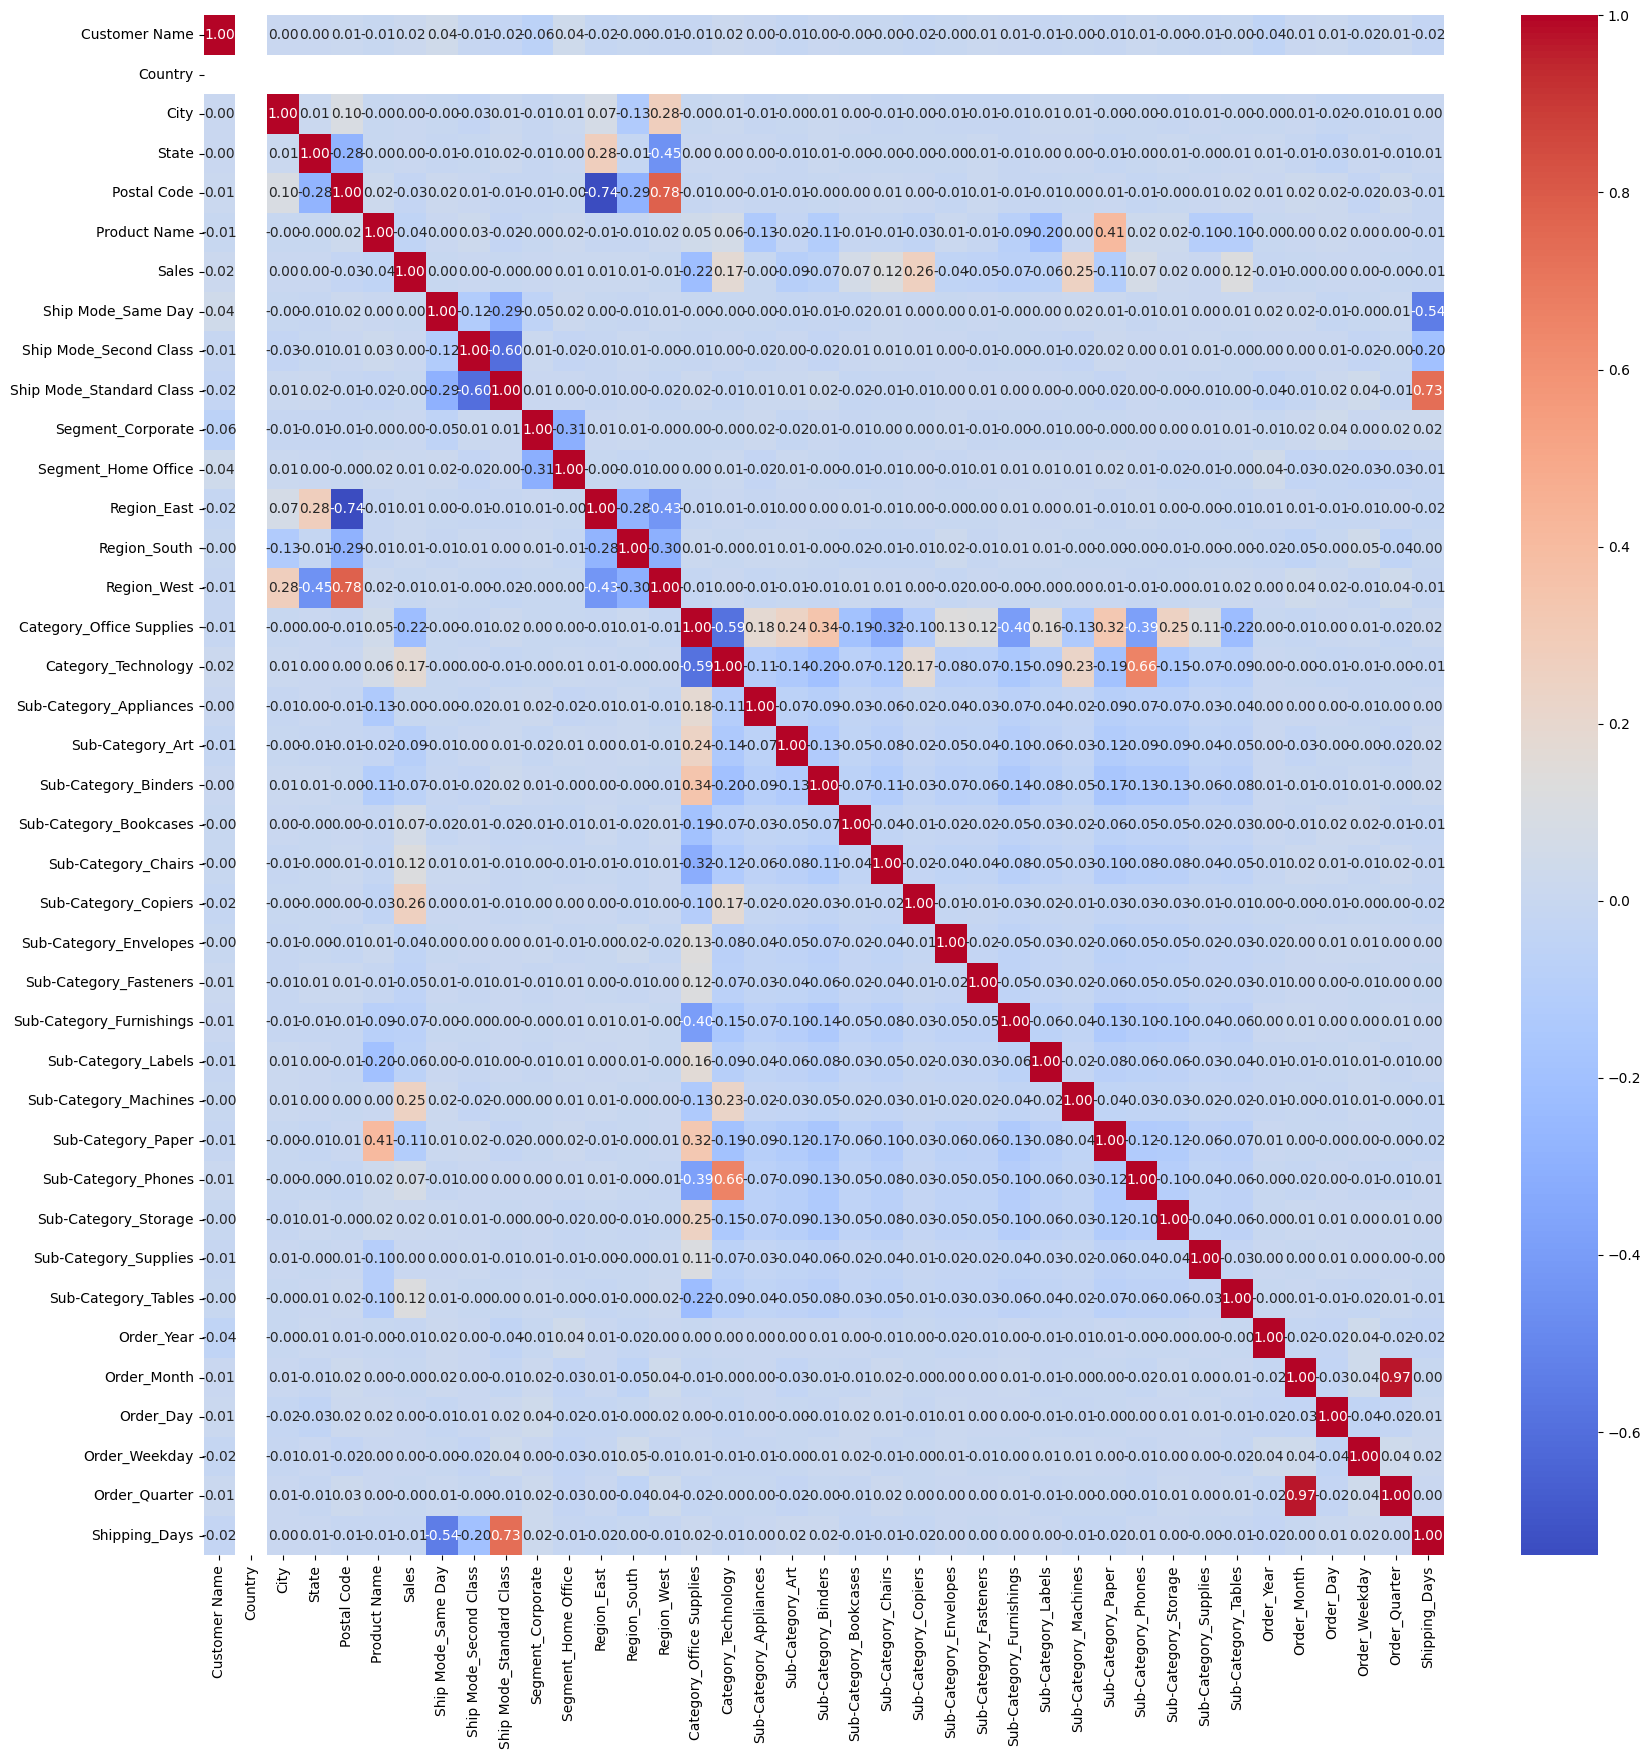

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
sns.heatmap(df_cleaned.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()


In [ ]:
df_cleaned.columns

Index(['Customer Name', 'Country', 'City', 'State', 'Postal Code',
       'Product Name', 'Sales', 'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office',
       'Region_East', 'Region_South', 'Region_West',
       'Category_Office Supplies', 'Category_Technology',
       'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders',
       'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers',
       'Sub-Category_Envelopes', 'Sub-Category_Fasteners',
       'Sub-Category_Furnishings', 'Sub-Category_Labels',
       'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones',
       'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables',
       'Order_Year', 'Order_Month', 'Order_Day', 'Order_Weekday',
       'Order_Quarter', 'Shipping_Days'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

# Numeric columns
numeric_cols = ['Sales', 'Shipping_Days', 'Order_Year', 'Order_Month',
                'Order_Day', 'Order_Weekday', 'Order_Quarter']

scaler = StandardScaler()
df_cleaned[numeric_cols] = scaler.fit_transform(df_cleaned[numeric_cols])


In [ ]:
df_cleaned

,Customer Name,Country,City,State,Postal Code,Product Name,Sales,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,...,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_Weekday,Order_Quarter,Shipping_Days
0,166,0,194,15,42420.0,386,0.049776,0,1,0,...,0,0,0,0,0.245404,0.969465,-0.855317,-0.455745,1.053706,-0.549362
1,166,0,194,15,42420.0,838,0.799801,0,1,0,...,0,0,0,0,0.245404,0.969465,-0.855317,-0.455745,1.053706,-0.549362
2,201,0,265,3,90036.0,1432,-0.344944,0,1,0,...,0,0,0,0,0.245404,-0.554118,-0.398346,-1.373037,-0.837734,0.022222
3,687,0,153,8,33311.0,366,1.159887,0,0,1,...,0,0,0,1,-0.644334,0.664749,-0.512589,-0.914391,1.053706,1.736974
4,687,0,153,8,33311.0,573,-0.332580,0,0,1,...,0,1,0,0,-0.644334,0.664749,-0.512589,-0.914391,1.053706,1.736974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,663,0,80,11,60610.0,408,-0.362215,0,0,1,...,0,0,0,0,0.245404,-0.858834,0.629839,1.378840,-0.837734,1.736974
9796,164,0,483,33,43615.0,277,-0.351730,0,0,1,...,0,0,0,0,-0.644334,-2.077701,-0.398346,-0.914391,-1.783455,0.593806
9797,164,0,483,33,43615.0,724,0.007052,0,0,1,...,1,0,0,0,-0.644334,-2.077701,-0.398346,-0.914391,-1.783455,0.593806
9798,164,0,483,33,43615.0,148,-0.326183,0,0,1,...,1,0,0,0,-0.644334,-2.077701,-0.398346,-0.914391,-1.783455,0.593806


In [ ]:
df_cleaned.columns

Index(['Customer Name', 'Country', 'City', 'State', 'Postal Code',
       'Product Name', 'Sales', 'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office',
       'Region_East', 'Region_South', 'Region_West',
       'Category_Office Supplies', 'Category_Technology',
       'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders',
       'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers',
       'Sub-Category_Envelopes', 'Sub-Category_Fasteners',
       'Sub-Category_Furnishings', 'Sub-Category_Labels',
       'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones',
       'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables',
       'Order_Year', 'Order_Month', 'Order_Day', 'Order_Weekday',
       'Order_Quarter', 'Shipping_Days'],
      dtype='object')

In [ ]:
df_cleaned[['Customer Name', 'City', 'State', 'Postal Code',
       'Product Name',]]

,Customer Name,City,State,Postal Code,Product Name
0,166,194,15,42420.0,386
1,166,194,15,42420.0,838
2,201,265,3,90036.0,1432
3,687,153,8,33311.0,366
4,687,153,8,33311.0,573
...,...,...,...,...,...
9795,663,80,11,60610.0,408
9796,164,483,33,43615.0,277
9797,164,483,33,43615.0,724
9798,164,483,33,43615.0,148


In [ ]:
df_cleaned.drop(columns=['Country'], inplace=True)

In [ ]:
df_cleaned.shape

(9800, 38)

In [ ]:
df_cleaned

,Customer Name,City,State,Postal Code,Product Name,Sales,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,...,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_Weekday,Order_Quarter,Shipping_Days
0,166,194,15,42420.0,386,0.049776,0,1,0,0,...,0,0,0,0,0.245404,0.969465,-0.855317,-0.455745,1.053706,-0.549362
1,166,194,15,42420.0,838,0.799801,0,1,0,0,...,0,0,0,0,0.245404,0.969465,-0.855317,-0.455745,1.053706,-0.549362
2,201,265,3,90036.0,1432,-0.344944,0,1,0,1,...,0,0,0,0,0.245404,-0.554118,-0.398346,-1.373037,-0.837734,0.022222
3,687,153,8,33311.0,366,1.159887,0,0,1,0,...,0,0,0,1,-0.644334,0.664749,-0.512589,-0.914391,1.053706,1.736974
4,687,153,8,33311.0,573,-0.332580,0,0,1,0,...,0,1,0,0,-0.644334,0.664749,-0.512589,-0.914391,1.053706,1.736974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,663,80,11,60610.0,408,-0.362215,0,0,1,1,...,0,0,0,0,0.245404,-0.858834,0.629839,1.378840,-0.837734,1.736974
9796,164,483,33,43615.0,277,-0.351730,0,0,1,1,...,0,0,0,0,-0.644334,-2.077701,-0.398346,-0.914391,-1.783455,0.593806
9797,164,483,33,43615.0,724,0.007052,0,0,1,1,...,1,0,0,0,-0.644334,-2.077701,-0.398346,-0.914391,-1.783455,0.593806
9798,164,483,33,43615.0,148,-0.326183,0,0,1,1,...,1,0,0,0,-0.644334,-2.077701,-0.398346,-0.914391,-1.783455,0.593806


In [ ]:
print(df_cleaned.shape)
print(df_cleaned.isna().sum())
print(df_cleaned.head())


(9800, 38)
Customer Name               0
City                        0
State                       0
Postal Code                 0
Product Name                0
Sales                       0
Ship Mode_Same Day          0
Ship Mode_Second Class      0
Ship Mode_Standard Class    0
Segment_Corporate           0
Segment_Home Office         0
Region_East                 0
Region_South                0
Region_West                 0
Category_Office Supplies    0
Category_Technology         0
Sub-Category_Appliances     0
Sub-Category_Art            0
Sub-Category_Binders        0
Sub-Category_Bookcases      0
Sub-Category_Chairs         0
Sub-Category_Copiers        0
Sub-Category_Envelopes      0
Sub-Category_Fasteners      0
Sub-Category_Furnishings    0
Sub-Category_Labels         0
Sub-Category_Machines       0
Sub-Category_Paper          0
Sub-Category_Phones         0
Sub-Category_Storage        0
Sub-Category_Supplies       0
Sub-Category_Tables         0
Order_Year                  0

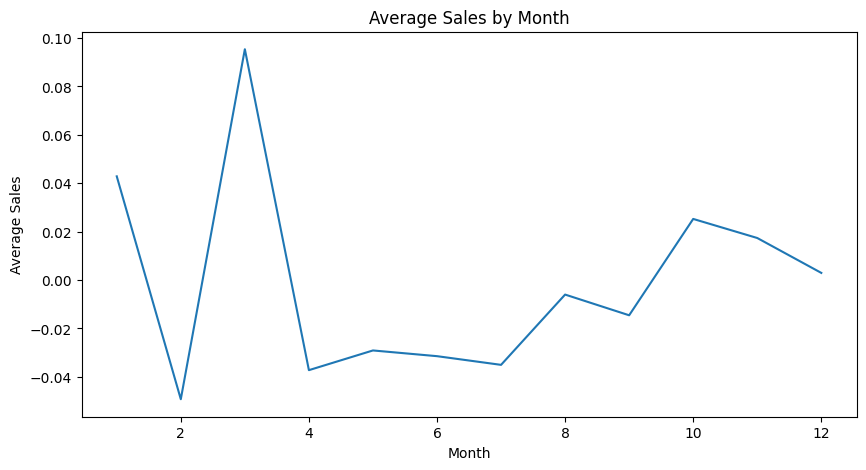

In [ ]:
# Monthly sales
df_cleaned['Order_Month_unscaled'] = df['Order Date'].dt.month
monthly_sales = df_cleaned.groupby('Order_Month_unscaled')['Sales'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

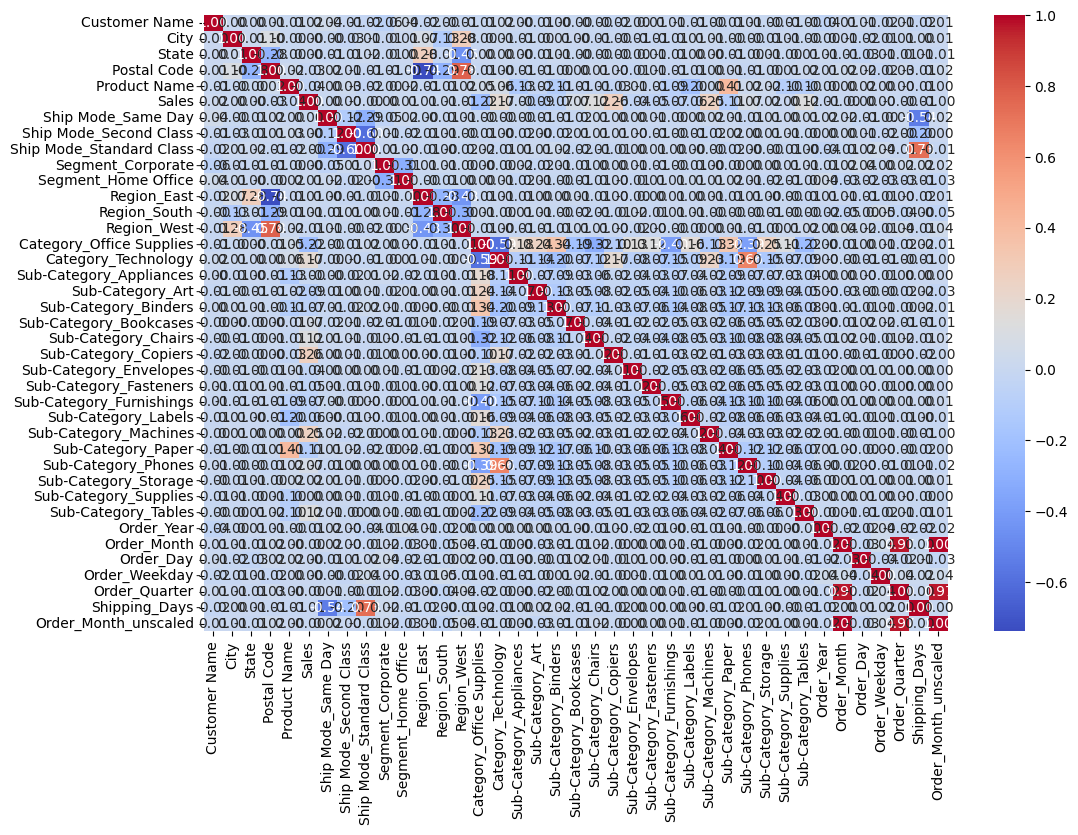

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_cleaned.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()


In [ ]:
from scipy.stats import pearsonr


selected_features = [
    'Shipping_Days', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_Weekday', 'Order_Quarter',
    'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class',
    'Segment_Corporate', 'Segment_Home Office',
    'Region_East', 'Region_South', 'Region_West'
]

target_col = 'Sales'

pearson_df = pearson_correlation(df_cleaned, target_col, selected_features)
print(pearson_df)



                     Feature  Pearson Correlation
11               Region_East             0.009686
10       Segment_Home Office             0.009388
12              Region_South             0.008985
7     Ship Mode_Second Class             0.004526
3                  Order_Day             0.003301
9          Segment_Corporate             0.002496
4              Order_Weekday             0.001575
6         Ship Mode_Same Day             0.000762
2                Order_Month            -0.000134
5              Order_Quarter            -0.001434
8   Ship Mode_Standard Class            -0.003734
13               Region_West            -0.005024
0              Shipping_Days            -0.005712
1                 Order_Year            -0.010624


In [ ]:
numeric_cols = df_cleaned.select_dtypes(include=['int64','float64']).columns.tolist()
print(numeric_cols)


['Customer Name', 'City', 'State', 'Postal Code', 'Product Name', 'Sales', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office', 'Region_East', 'Region_South', 'Region_West', 'Category_Office Supplies', 'Category_Technology', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_Weekday', 'Order_Quarter', 'Shipping_Days']


In [ ]:
# Sales কে High / Low category তে ভাগ করা
df_cleaned['Sales_cat'] = pd.qcut(df_cleaned['Sales'], q=2, labels=['Low','High'])
target = 'Sales_cat'


In [ ]:
categorical_features = [
    'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class',
    'Segment_Corporate', 'Segment_Home Office',
    'Region_East', 'Region_South', 'Region_West',
    'Category_Office Supplies', 'Category_Technology',
    'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders',
    'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers',
    'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings',
    'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper',
    'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies',
    'Sub-Category_Tables'
]


In [ ]:
from scipy.stats import chi2_contingency

def chi2_feature_selection(df, categorical_features, target, alpha=0.05):
    results = []

    for feature in categorical_features:
        if feature not in df.columns:
            continue

        contingency_table = pd.crosstab(df[feature], df[target])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        decision = "Reject Null (Keep Feature)" if p < alpha else "Accept Null (Drop Feature)"

        results.append({
            'Feature': feature,
            'chi2_statistic': chi2,
            'p_value': p,
            'Decision': decision
        })

    return pd.DataFrame(results).sort_values(by='chi2_statistic', ascending=False)



In [ ]:
chi2_results = chi2_feature_selection(df_cleaned, categorical_features, target)
print(chi2_results)



                     Feature  chi2_statistic        p_value  \
8   Category_Office Supplies     1756.478874   0.000000e+00   
9        Category_Technology      771.946305  6.785401e-170   
14       Sub-Category_Chairs      590.794048  1.683420e-130   
12      Sub-Category_Binders      469.969334  3.254182e-104   
22       Sub-Category_Phones      426.088210   1.154244e-94   
11          Sub-Category_Art      371.578184   8.483530e-83   
21        Sub-Category_Paper      300.280777   2.861539e-67   
25       Sub-Category_Tables      298.089239   8.591444e-67   
13    Sub-Category_Bookcases      217.226319   3.642598e-49   
17    Sub-Category_Fasteners      204.698928   1.970056e-46   
19       Sub-Category_Labels      196.514484   1.203600e-44   
23      Sub-Category_Storage      150.940765   1.079780e-34   
20     Sub-Category_Machines       91.543804   1.091491e-21   
15      Sub-Category_Copiers       64.449197   9.905371e-16   
10   Sub-Category_Appliances       41.042104   1.489849

In [ ]:
df_cleaned.shape

(9800, 40)

In [ ]:
# Dropable features: p_value >= 0.05 → Accept Null
dropable_features = chi2_results[chi2_results['Decision'] == "Accept Null (Drop Feature)"]['Feature'].tolist()
print("Dropable features:", dropable_features)


Dropable features: ['Segment_Corporate', 'Ship Mode_Standard Class', 'Ship Mode_Second Class', 'Segment_Home Office', 'Region_East', 'Ship Mode_Same Day', 'Region_South']


In [ ]:
df_final = df_cleaned.drop(columns=dropable_features)

# যদি temporary target column থাকে (Sales_cat), drop করুন
df_final = df_final.drop(columns=['Sales_cat'], errors='ignore')

# Check final shape and first rows
print("Final ML-ready dataset shape:", df_final.shape)
print(df_final.head())



Final ML-ready dataset shape: (9800, 32)
   Customer Name  City  State  Postal Code  Product Name     Sales  \
0            166   194     15      42420.0           386  0.049776   
1            166   194     15      42420.0           838  0.799801   
2            201   265      3      90036.0          1432 -0.344944   
3            687   153      8      33311.0           366  1.159887   
4            687   153      8      33311.0           573 -0.332580   

   Region_West  Category_Office Supplies  Category_Technology  \
0            0                         0                    0   
1            0                         0                    0   
2            1                         1                    0   
3            0                         0                    0   
4            0                         1                    0   

   Sub-Category_Appliances  ...  Sub-Category_Storage  Sub-Category_Supplies  \
0                        0  ...                     0              

In [ ]:
df_final.shape

(9800, 32)